In [1]:
import rasterio
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [12]:
dist_s1_dir = Path('val_products_transformer_optimized-max10_processed_2026-02-05')

In [17]:
dist_hls_dir = Path('dist_hls/validation_sites')
dist_hls_dir.exists()

True

In [22]:
ts_dirs_dist_hls = sorted(list(dist_hls_dir.glob('*/')))
sample_ts_dir_dist_hls = ts_dirs_dist_hls[0]
sample_ts_dir_dist_hls

PosixPath('dist_hls/validation_sites/builtnewalert__14RNU')

In [20]:
ts_dirs_dist_s1 = sorted(list(dist_s1_dir.glob('*/')))
sample_ts_dir_dist_s1 = ts_dirs_dist_s1[1]
sample_ts_dir_dist_s1

PosixPath('val_products_transformer_optimized-max10_processed_2026-02-05/builtnewalert__16SBF')

In [21]:
acq_files_dist_s1 = sorted(list(sample_ts_dir_dist_s1.rglob('OPERA*_GEN-DIST-STATUS-ACQ.tif')))
acq_files_dist_s1[:3]

[PosixPath('val_products_transformer_optimized-max10_processed_2026-02-05/builtnewalert__16SBF/OPERA_L3_DIST-ALERT-S1_T16SBF_20240104T235607Z_20260205T203507Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T16SBF_20240104T235607Z_20260205T203507Z_S1A_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('val_products_transformer_optimized-max10_processed_2026-02-05/builtnewalert__16SBF/OPERA_L3_DIST-ALERT-S1_T16SBF_20240110T000417Z_20260205T195451Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T16SBF_20240110T000417Z_20260205T195451Z_S1A_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('val_products_transformer_optimized-max10_processed_2026-02-05/builtnewalert__16SBF/OPERA_L3_DIST-ALERT-S1_T16SBF_20240116T235606Z_20260205T194232Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T16SBF_20240116T235606Z_20260205T194232Z_S1A_30_v0.1_GEN-DIST-STATUS-ACQ.tif')]

In [23]:
anom_files = sorted(list(sample_ts_dir_dist_hls.rglob('*_VEG-ANOM.tif')))
anom_files[:3]

[PosixPath('dist_hls/validation_sites/builtnewalert__14RNU/OPERA_L3_DIST-ALERT-HLS_T14RNU_20240104T171711Z_20240207T213436Z_S2A_30_v1/OPERA_L3_DIST-ALERT-HLS_T14RNU_20240104T171711Z_20240207T213436Z_S2A_30_v1_VEG-ANOM.tif'),
 PosixPath('dist_hls/validation_sites/builtnewalert__14RNU/OPERA_L3_DIST-ALERT-HLS_T14RNU_20240106T170709Z_20240207T213518Z_S2B_30_v1/OPERA_L3_DIST-ALERT-HLS_T14RNU_20240106T170709Z_20240207T213518Z_S2B_30_v1_VEG-ANOM.tif'),
 PosixPath('dist_hls/validation_sites/builtnewalert__14RNU/OPERA_L3_DIST-ALERT-HLS_T14RNU_20240109T170917Z_20240207T213600Z_L8_30_v1/OPERA_L3_DIST-ALERT-HLS_T14RNU_20240109T170917Z_20240207T213600Z_L8_30_v1_VEG-ANOM.tif')]

In [5]:
def open_one_arr(path):
    with rasterio.open(path) as src:
        return src.read(1)

def compute_count(ts_dir: Path, glob_pattern: str = '*GEN-DIST-STATUS-ACQ.tif') -> tuple:
    acq_files = sorted(list(ts_dir.rglob(glob_pattern)))
    status_arrs = list(map(open_one_arr, acq_files))
    status_arrs_stacked = np.stack(status_arrs, axis=0)

    valid_observations = (status_arrs_stacked != 255).astype(np.uint8).sum(axis=0)

    with rasterio.open(acq_files[0]) as ds:
        p = ds.profile

    return valid_observations, p,


In [24]:
interesting_dir = Path('val_products_transformer_optimized-max10_processed_2026-02-05/fire__22LDR')
valid_observations, p = compute_count(interesting_dir)

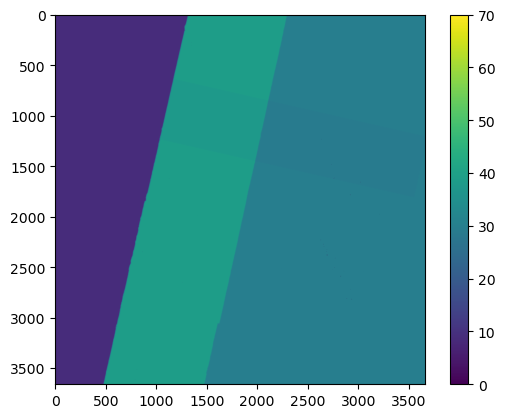

In [25]:
plt.imshow(valid_observations, vmin=0, vmax=70)
plt.colorbar()

In [30]:
valid_observations_hls, p = compute_count(sample_ts_dir_dist_hls, glob_pattern='*VEG-ANOM.tif')

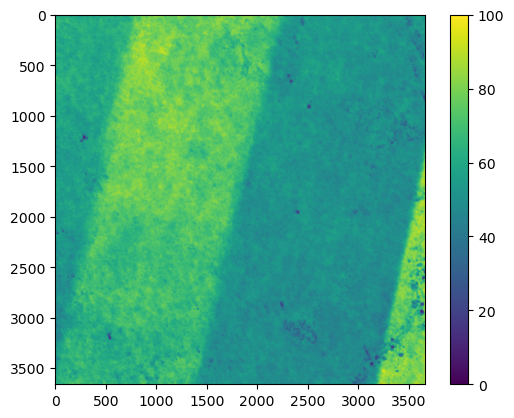

In [31]:
plt.imshow(valid_observations_hls, vmin=0, vmax=100)
plt.colorbar()

In [32]:
agg_dir_all = Path('aggregated_validation_dist_2024')

In [35]:
def serialize_count(ts_dir: Path, sensor: str = 's1') -> Path:
    if sensor not in ['s1', 'hls']:
        raise ValueError(f"Invalid sensor: {sensor}")
    glob_pattern = '*GEN-DIST-STATUS-ACQ.tif' if sensor == 's1' else '*VEG-ANOM.tif'
    agg_dir = agg_dir_all / ts_dir.name
    assert agg_dir.exists(), f"Aggregation directory {agg_dir} does not exist"
    mgrs_tile_id = ts_dir.name.split('__')[-1]
    out_path = agg_dir / f'{mgrs_tile_id}_count_2024_{sensor}.tif'
    arr_c, p_c = compute_count(ts_dir, glob_pattern=glob_pattern)
    with rasterio.open(out_path, 'w', **p_c) as dst:
        dst.write(arr_c, 1)
    return out_path

serialize_count(sample_ts_dir_dist_s1)



PosixPath('aggregated_validation_dist_2024/builtnewalert__16SBF/16SBF_count_2024_s1.tif')

In [40]:
[serialize_count(ts_dir, sensor='s1') for ts_dir in tqdm(ts_dirs_dist_s1)]

100%|██████████| 85/85 [02:14<00:00,  1.58s/it]


[PosixPath('aggregated_validation_dist_2024/builtnewalert__14RNU/14RNU_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__16SBF/16SBF_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__22KFA/22KFA_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__22LDQ/22LDQ_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__22MDT/22MDT_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__22MGB/22MGB_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__43QEU/43QEU_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__43QFE/43QFE_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__44PKB/44PKB_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__50SMF/50SMF_count_2024_s1.tif'),
 PosixPath('aggregated_validation_dist_2024/builtnewalert__52TDP/52TDP_count_202

In [ ]:
[serialize_count(ts_dir, sensor='hls') for ts_dir in tqdm(ts_dirs_dist_hls[:])]

100%|██████████| 1/1 [00:05<00:00,  5.51s/it]


[PosixPath('aggregated_validation_dist_2024/cropnew__17TPG/17TPG_count_2024_hls.tif')]